In [3]:
from src.data import load_split, load_rul

train = load_split("data/raw/train_FD001.txt")
test = load_split("data/raw/test_FD001.txt")
rul = load_rul("data/raw/RUL_FD001.txt")

print(train.shape, test.shape, rul.shape)
train.head()

(20631, 26) (13096, 26) (100, 1)


,unit,cycle,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


<Axes: >

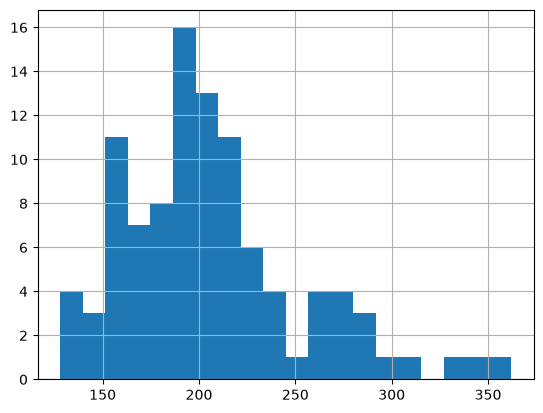

In [4]:
life = train.groupby("unit")["cycle"].max()
print(life.describe())
life.hist(bins=20)

In [5]:
print("Missing values:", train.isna().sum().sum())
print()
print(train.drop(columns=["unit", "cycle"]).std().round(4))

Missing values: 0

setting_1     0.0022
setting_2     0.0003
setting_3     0.0000
s_1           0.0000
s_2           0.5001
s_3           6.1311
s_4           9.0006
s_5           0.0000
s_6           0.0014
s_7           0.8851
s_8           0.0710
s_9          22.0829
s_10          0.0000
s_11          0.2671
s_12          0.7376
s_13          0.0719
s_14         19.0762
s_15          0.0375
s_16          0.0000
s_17          1.5488
s_18          0.0000
s_19          0.0000
s_20          0.1807
s_21          0.1083
dtype: float64


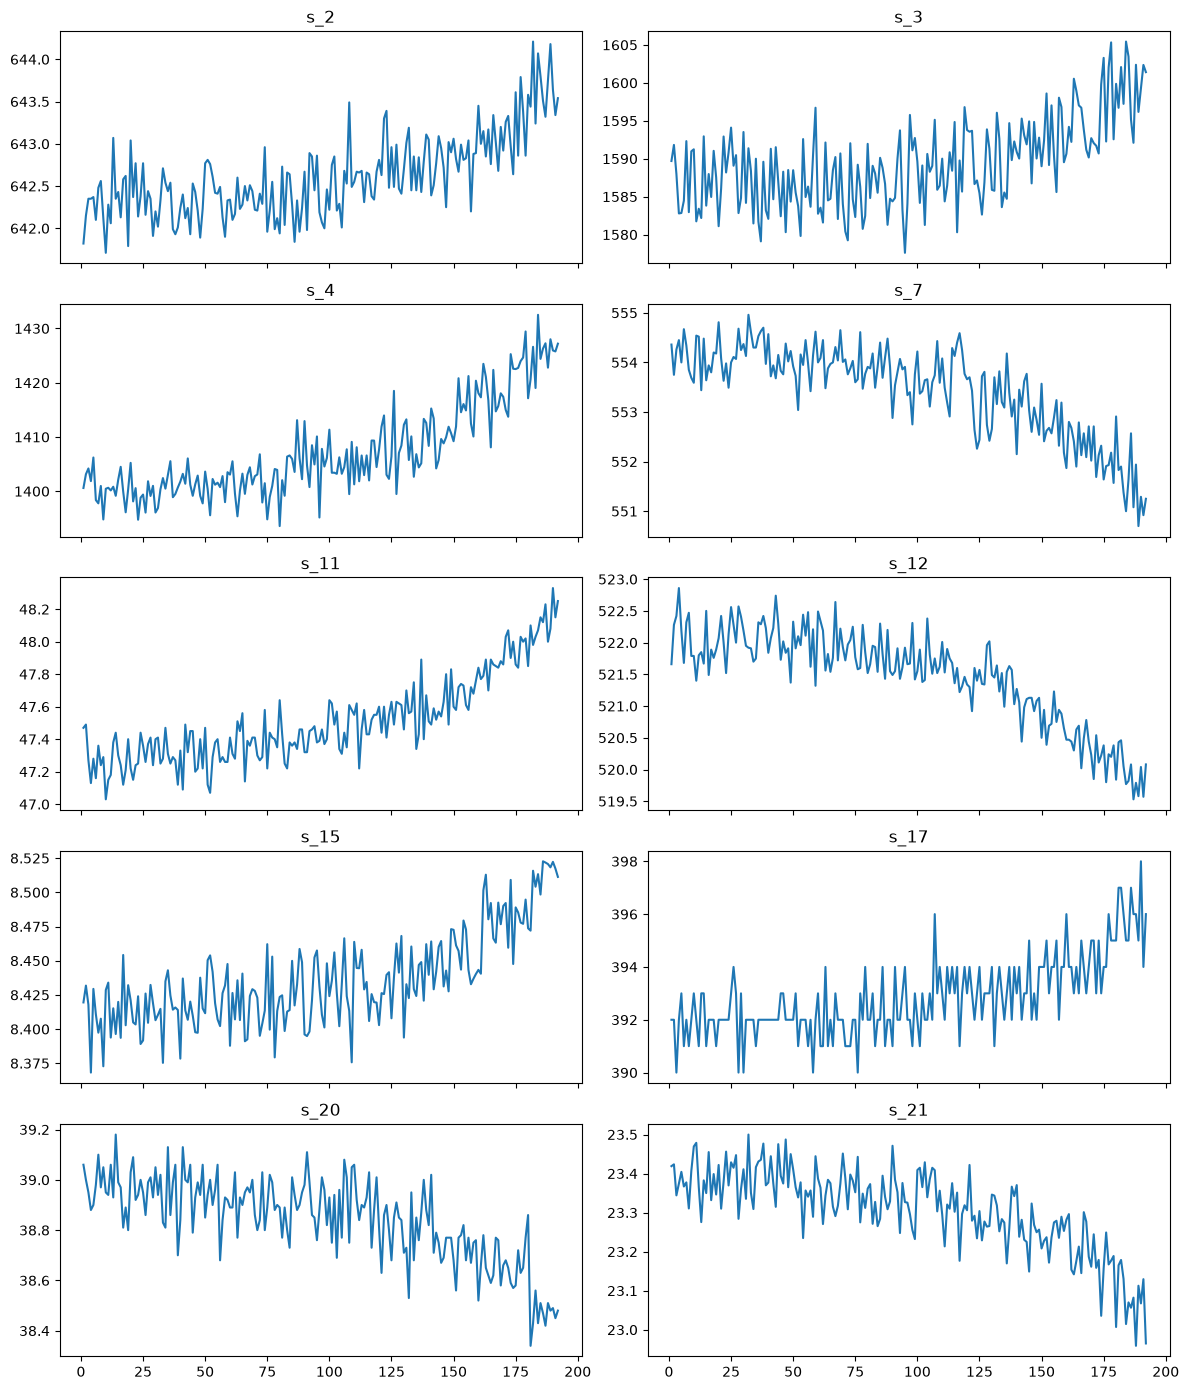

In [6]:
import matplotlib.pyplot as plt

engine = train[train["unit"] == 1]
sensors = ["s_2", "s_3", "s_4", "s_7", "s_11", "s_12", "s_15", "s_17", "s_20", "s_21"]

fig, axes = plt.subplots(5, 2, figsize=(12, 14), sharex=True)
for ax, s in zip(axes.flat, sensors):
    ax.plot(engine["cycle"], engine[s])
    ax.set_title(s)
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd

last_cycle = test.groupby("unit")["cycle"].max()
check = pd.DataFrame({"last_cycle": last_cycle.values, "true_rul": rul["rul"].values})
check["total_life"] = check["last_cycle"] + check["true_rul"]
print(check.head())
print(check.describe())

   last_cycle  true_rul  total_life
0          31       112         143
1          49        98         147
2         126        69         195
3         106        82         188
4          98        91         189
       last_cycle   true_rul  total_life
count  100.000000  100.00000  100.000000
mean   130.960000   75.52000  206.480000
std     53.593479   41.76497   44.041872
min     31.000000    7.00000  141.000000
25%     88.750000   32.75000  174.750000
50%    133.500000   86.00000  199.000000
75%    164.250000  112.25000  227.750000
max    303.000000  145.00000  341.000000
